<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/12_Numerical_Stability_and_Initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Numerical Stability and Initialization

The way a neural network's weights are initialized can strongly affect how well the model trains.

Poor initialization can cause gradients to become:

- **too small**, leading to the **vanishing gradient problem**, or
- **too large**, leading to the **exploding gradient problem**.

Both problems make optimization difficult. Small gradients cause the early layers to learn very slowly, while large gradients can make training unstable.

Good initialization helps keep activations and gradients at reasonable values as they move through the network. It also ensures that different neurons begin with different weights and can learn different features.

In this section, we examine:

- vanishing and exploding gradients,
- why weights should not all begin with the same value, and
- how initialization methods such as **Xavier initialization** improve training stability.

## Vanishing and Exploding Gradients

Deep neural networks are trained using **backpropagation**, where gradients are propagated backward through many layers. During this process, gradients are repeatedly multiplied as they move from the output layer toward the input layer.

As a result, two common problems may occur:

- **Vanishing gradients:** Gradients become progressively smaller, eventually approaching zero. Earlier layers receive almost no updates and learn very slowly.
- **Exploding gradients:** Gradients grow excessively large, causing unstable parameter updates and making training difficult or impossible.

These issues become more severe as the number of network layers increases. Consequently, selecting suitable activation functions and weight initialization methods is essential for stable and efficient training.

### 5.4.1.1 Vanishing Gradients

The **vanishing gradient problem** occurs when gradients become extremely small during backpropagation. As gradients are propagated through multiple layers, repeated multiplication by small values causes them to approach zero.

When this happens:

- Early layers receive almost no parameter updates.
- Learning becomes very slow.
- The network may fail to learn meaningful features.

One major cause of vanishing gradients is the **sigmoid activation function**. As discussed earlier, the sigmoid derivative is very small for large positive or negative inputs. When many sigmoid layers are stacked together, these small derivatives are multiplied repeatedly, causing the gradients to vanish.

Modern neural networks commonly use the **ReLU activation function**, whose gradient remains much larger for positive inputs. This significantly reduces the vanishing gradient problem and enables the successful training of deeper networks.

In [ ]:
!pip install -q D2L --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.0 MB/s eta 0:00:00


In [ ]:
%matplotlib inline
import tensorflow as tf
from d2l import tensorflow as d2l


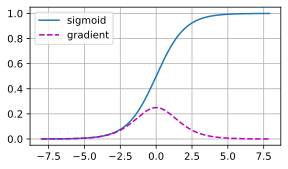

In [ ]:
x = tf.Variable(tf.range(-8.0, 8.0, 0.1))
with tf.GradientTape() as t:
    y = tf.nn.sigmoid(x)
d2l.plot(x.numpy(), [y.numpy(), t.gradient(y, x).numpy()],
         legend=['sigmoid', 'gradient'], figsize=(4.5, 2.5))



The gradient reaches its maximum near x = 0.
As the input moves far from zero, the gradient approaches 0.
During backpropagation, multiplying many near-zero gradients causes the overall gradient to disappear.
Consequently, the earlier layers learn very slowly.


**Figure:** Sigmoid activation function and its gradient.

**Observation**

- The blue curve represents the sigmoid activation function.
- The dashed curve represents the gradient (derivative) of the sigmoid.
- The gradient is largest when the input is near **0**.
- As the input becomes very positive or very negative, the gradient approaches **0**.
- During backpropagation, multiplying many near-zero gradients causes the gradients in earlier layers to become extremely small.
- As a result, early layers learn very slowly or stop learning altogether. This is known as the **vanishing gradient problem**.
- Modern neural networks typically use **ReLU** instead of sigmoid in hidden layers because ReLU greatly reduces this problem.


###  Exploding Gradients

The **exploding gradient problem** occurs when gradients become excessively large during backpropagation. As the gradients are propagated backward through many layers, repeated multiplication by values greater than one can cause them to increase rapidly.

When this happens:

- Weight updates become excessively large.
- The training process becomes unstable.
- The loss may oscillate or diverge instead of decreasing.
- The model may fail to converge.

Although exploding gradients are less common than vanishing gradients, they can occur in very deep neural networks and recurrent neural networks (RNNs).

Common techniques for reducing exploding gradients include:

- Careful parameter initialization.
- Gradient clipping.
- Appropriate learning rates.

In [ ]:
M = tf.random.normal((4, 4))
print('a single matrix \n', M)
for i in range(100):
    M = tf.matmul(M, tf.random.normal((4, 4)))
print('after multiplying 100 matrices\n', M.numpy())


a single matrix 
 tf.Tensor(
[[-0.46086776 -1.3168781   1.3256029   0.16939351]
 [-0.181688   -0.30798346 -0.12904485  0.94608825]
 [ 0.436702   -0.35293677  1.2712688  -0.9214245 ]
 [-0.52337915 -0.521091    0.24847779  0.47993863]], shape=(4, 4), dtype=float32)
after multiplying 100 matrices
 [[ 6.4025734e+25 -5.0007238e+26  7.7212260e+25 -1.6300827e+26]
 [ 2.1117856e+25 -1.6494070e+26  2.5467211e+25 -5.3765618e+25]
 [-5.3979923e+24  4.2160970e+25 -6.5097470e+24  1.3743184e+25]
 [ 2.7248507e+25 -2.1282440e+26  3.2860576e+25 -6.9374248e+25]]


### Demonstration: Exploding Gradients

The code above demonstrates how repeated matrix multiplication can produce extremely large values. A random \(4 \times 4\) matrix is multiplied by another random matrix 100 times.


**Observation**

- The initial matrix contains relatively small values.
- After repeated multiplication, the values become extremely large (e.g., on the order of \(10^{24}\)).
- This illustrates how gradients can grow uncontrollably when propagated through many layers.
- Excessively large gradients lead to unstable weight updates and may prevent the model from converging.

## Breaking the Symmetry

Another challenge in training neural networks is **symmetry** during parameter initialization.

If all neurons in the same hidden layer are initialized with **identical weights and biases**, they will produce the same outputs during forward propagation. Consequently, during backpropagation they receive identical gradients and are updated in exactly the same way.

As a result:

- All neurons learn the same features.
- The hidden layer behaves like a single neuron.
- The network cannot fully utilize its learning capacity.

To prevent this problem, weights are initialized with **small random values** instead of identical values. Random initialization breaks the symmetry, allowing each neuron to learn different features from the training data.

## Parameter Initialization

One effective way to reduce problems such as vanishing gradients, exploding gradients, and symmetry is through **careful parameter initialization**.

Rather than assigning arbitrary values to the weights, modern deep learning frameworks use initialization methods that help maintain stable activations and gradients during training.

In the following subsections, we examine two common initialization strategies:

- **Default Initialization** – the built-in initialization provided by deep learning frameworks.
- **Xavier Initialization** – a method that selects the initial weight variance based on the number of input and output neurons, improving training stability.

### Default Initialization

Most deep learning frameworks automatically initialize model parameters when a layer is created.

These default initialization methods are designed to provide reasonable starting weights for training and generally work well for many practical applications. However, for deeper networks or specialized architectures, more advanced initialization techniques such as Xavier initialization often provide better training stability.

### Xavier (Glorot) Initialization

Random initialization breaks the symmetry between neurons, but randomly choosing any values is not always sufficient. If the initial weights are too small, gradients may vanish during backpropagation. If the weights are too large, gradients may explode.

**Xavier (Glorot) Initialization** addresses this problem by selecting the initial weights according to the number of input and output neurons in a layer. The goal is to keep the activations and gradients at approximately the same scale as they propagate through the network, resulting in more stable and efficient training.

For a layer with \(n_{in}\) input neurons and \(n_{out}\) output neurons, Xavier initialization samples the weights from the following uniform distribution:

$$
W \sim U\left(-\sqrt{\frac{6}{n_{in}+n_{out}}},\;
\sqrt{\frac{6}{n_{in}+n_{out}}}\right)
$$

where:

- \(n_{in}\) is the number of input neurons.
- \(n_{out}\) is the number of output neurons.
- \(U(a,b)\) denotes a **uniform distribution**, meaning the initial weights are randomly selected between the lower and upper limits.

The key idea is that the initialization range automatically adjusts to the size of the layer. This helps prevent vanishing and exploding gradients while improving the stability of the training process.

Fortunately, modern deep learning frameworks implement Xavier initialization automatically.

In [ ]:
initializer = tf.keras.initializers.GlorotUniform()

model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        256,
        activation='relu',
        kernel_initializer=initializer
    ),
    tf.keras.layers.Dense(10)
])

In TensorFlow, **GlorotUniform** is the implementation of **Xavier Initialization**. It automatically computes an appropriate range for the initial weights based on the number of input and output neurons, helping the model train more efficiently.

## Summary

In this section, we examined how parameter initialization affects the training of deep neural networks.

- Poor initialization can lead to **vanishing gradients**, causing earlier layers to learn very slowly.
- Large initial weights may produce **exploding gradients**, resulting in unstable training.
- Initializing all weights with the same value creates **symmetry**, preventing neurons from learning different features.
- Modern deep learning frameworks provide effective default initialization methods.
- **Xavier (Glorot) Initialization** scales the initial weights according to the number of input and output neurons, helping maintain stable activations and gradients throughout the network.

Proper parameter initialization improves training stability, accelerates convergence, and enables the successful training of deeper neural networks.